In [2]:

import jax
import jax.numpy as jnp
from flax import nnx

from probjax.nn.nets.flows import AdditiveCouplingFlow, AffineAutoregressiveFlow


In [14]:
p = AffineAutoregressiveFlow(4, 5, nnx.Rngs(1))

graph_def, params, state = nnx.split(p, nnx.Param,...)


In [15]:
x1 = jax.random.normal(jax.random.PRNGKey(0), (1000, 4)) -2
x2 = jax.random.normal(jax.random.PRNGKey(1), (1000, 4)) +2

xs = jnp.concatenate([x1, x2], axis=0)

In [16]:
xs.shape

(2000, 4)

In [17]:
def loss(params):
    p = nnx.merge(graph_def, params, state)
    return -jnp.mean(p.logpdf(xs))

In [19]:
loss(params)

Array(23.929077, dtype=float32)

In [20]:
import optax

optimizer = optax.adam(1e-3)

@jax.jit
def update(params, opt_state):
    loss_val, grads = jax.value_and_grad(loss)(params)
    updates, opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return loss_val, new_params, opt_state

In [21]:
opt_state = optimizer.init(params)

In [22]:
for i in range(1000):
    loss_val, params, opt_state = update(params, opt_state)
    print(loss_val)

23.929077
23.904594
23.879818
23.854616
23.828915
23.802696
23.775898
23.748478
23.720415
23.691658
23.662146
23.631865
23.600712
23.568668
23.53571
23.501743
23.466688
23.430515
23.39317
23.354557
23.314579
23.273243
23.230448
23.18608
23.140102
23.092377
23.042812
22.991325
22.937807
22.882223
22.824415
22.76412
22.701384
22.636076
22.567926
22.496868
22.422712
22.34523
22.264315
22.179642
22.091158
21.998423
21.90135
21.799692
21.692907
21.580713
21.462994
21.33902
21.208672
21.071194
20.926212
20.773134
20.611517
20.440273
20.259108
20.06683
19.863447
19.647348
19.418446
19.175913
18.919159
18.64817
18.362337
18.063137
17.750345
17.42491
17.089903
16.745325
16.396103
16.044304
15.695301
15.35595
15.032366
14.729469
14.448652
14.19236
13.964656
13.75114
13.503383
13.208303
12.898159
12.596387
12.309917
12.041176
11.794316
11.57643
11.391685
11.227024
11.070153
10.921534
10.788203
10.664468
10.539276
10.400146
10.245203
10.075907
9.897323
9.71765
9.543818
9.383844
9.241846
9.117155
9

In [23]:
nnx.update(p, params)

In [24]:
samples = p.sample(jax.random.PRNGKey(0), (1000, ))

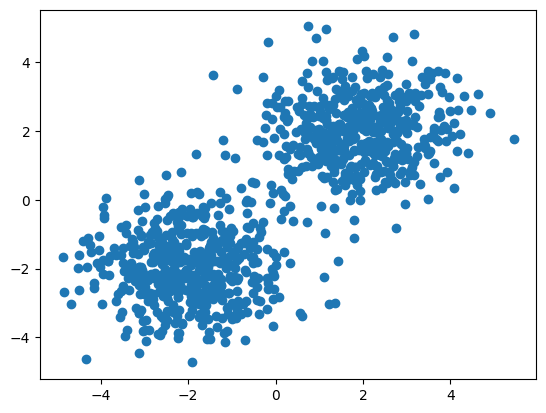

In [25]:
import matplotlib.pyplot as plt

plt.scatter(samples[:, 0], samples[:, 1])